In [1]:
import os
os.environ['KMP_DUPLICATE_LIB_OK'] = 'True'

In [2]:
import torch 
import torch.nn as nn
import numpy as np 
import pandas as pd 
import matplotlib.pylab as plt 

In [3]:
df = pd.read_csv('NYCTaxiFares.csv')

In [4]:
df.head()

,pickup_datetime,fare_amount,fare_class,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude,passenger_count
0,2010-04-19 08:17:56 UTC,6.5,0,-73.992365,40.730521,-73.975499,40.744746,1
1,2010-04-17 15:43:53 UTC,6.9,0,-73.990078,40.740558,-73.974232,40.744114,1
2,2010-04-17 11:23:26 UTC,10.1,1,-73.994149,40.751118,-73.960064,40.766235,2
3,2010-04-11 21:25:03 UTC,8.9,0,-73.990485,40.756422,-73.971205,40.748192,1
4,2010-04-17 02:19:01 UTC,19.7,1,-73.990976,40.734202,-73.905956,40.743115,1


In [5]:
df['fare_amount'].describe()

count    120000.000000
mean         10.040326
std           7.500134
min           2.500000
25%           5.700000
50%           7.700000
75%          11.300000
max          49.900000
Name: fare_amount, dtype: float64

In [6]:
def haversine_distance(df, lat1, long1, lat2, long2):
    r = 6371
       
    phi1 = np.radians(df[lat1])
    phi2 = np.radians(df[lat2])
    
    delta_phi = np.radians(df[lat2]-df[lat1])
    delta_lambda = np.radians(df[long2]-df[long1])
     
    a = np.sin(delta_phi/2)**2 + np.cos(phi1) * np.cos(phi2) * np.sin(delta_lambda/2)**2
    c = 2 * np.arctan2(np.sqrt(a), np.sqrt(1-a))
    d = (r * c)

    return d

In [7]:
df['dist_km'] = haversine_distance(df,'pickup_latitude','pickup_longitude','dropoff_latitude','dropoff_longitude')

In [8]:
df.columns

Index(['pickup_datetime', 'fare_amount', 'fare_class', 'pickup_longitude',
       'pickup_latitude', 'dropoff_longitude', 'dropoff_latitude',
       'passenger_count', 'dist_km'],
      dtype='str')

In [9]:
df.head()

,pickup_datetime,fare_amount,fare_class,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude,passenger_count,dist_km
0,2010-04-19 08:17:56 UTC,6.5,0,-73.992365,40.730521,-73.975499,40.744746,1,2.126312
1,2010-04-17 15:43:53 UTC,6.9,0,-73.990078,40.740558,-73.974232,40.744114,1,1.392307
2,2010-04-17 11:23:26 UTC,10.1,1,-73.994149,40.751118,-73.960064,40.766235,2,3.326763
3,2010-04-11 21:25:03 UTC,8.9,0,-73.990485,40.756422,-73.971205,40.748192,1,1.864129
4,2010-04-17 02:19:01 UTC,19.7,1,-73.990976,40.734202,-73.905956,40.743115,1,7.231321


In [10]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 120000 entries, 0 to 119999
Data columns (total 9 columns):
 #   Column             Non-Null Count   Dtype  
---  ------             --------------   -----  
 0   pickup_datetime    120000 non-null  str    
 1   fare_amount        120000 non-null  float64
 2   fare_class         120000 non-null  int64  
 3   pickup_longitude   120000 non-null  float64
 4   pickup_latitude    120000 non-null  float64
 5   dropoff_longitude  120000 non-null  float64
 6   dropoff_latitude   120000 non-null  float64
 7   passenger_count    120000 non-null  int64  
 8   dist_km            120000 non-null  float64
dtypes: float64(6), int64(2), str(1)
memory usage: 10.9 MB


In [11]:
df['pickup_datetime'] = pd.to_datetime(df['pickup_datetime'])

In [12]:
df.head()

,pickup_datetime,fare_amount,fare_class,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude,passenger_count,dist_km
0,2010-04-19 08:17:56+00:00,6.5,0,-73.992365,40.730521,-73.975499,40.744746,1,2.126312
1,2010-04-17 15:43:53+00:00,6.9,0,-73.990078,40.740558,-73.974232,40.744114,1,1.392307
2,2010-04-17 11:23:26+00:00,10.1,1,-73.994149,40.751118,-73.960064,40.766235,2,3.326763
3,2010-04-11 21:25:03+00:00,8.9,0,-73.990485,40.756422,-73.971205,40.748192,1,1.864129
4,2010-04-17 02:19:01+00:00,19.7,1,-73.990976,40.734202,-73.905956,40.743115,1,7.231321


In [13]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 120000 entries, 0 to 119999
Data columns (total 9 columns):
 #   Column             Non-Null Count   Dtype              
---  ------             --------------   -----              
 0   pickup_datetime    120000 non-null  datetime64[us, UTC]
 1   fare_amount        120000 non-null  float64            
 2   fare_class         120000 non-null  int64              
 3   pickup_longitude   120000 non-null  float64            
 4   pickup_latitude    120000 non-null  float64            
 5   dropoff_longitude  120000 non-null  float64            
 6   dropoff_latitude   120000 non-null  float64            
 7   passenger_count    120000 non-null  int64              
 8   dist_km            120000 non-null  float64            
dtypes: datetime64[us, UTC](1), float64(6), int64(2)
memory usage: 8.2 MB


In [14]:
df.head()

,pickup_datetime,fare_amount,fare_class,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude,passenger_count,dist_km
0,2010-04-19 08:17:56+00:00,6.5,0,-73.992365,40.730521,-73.975499,40.744746,1,2.126312
1,2010-04-17 15:43:53+00:00,6.9,0,-73.990078,40.740558,-73.974232,40.744114,1,1.392307
2,2010-04-17 11:23:26+00:00,10.1,1,-73.994149,40.751118,-73.960064,40.766235,2,3.326763
3,2010-04-11 21:25:03+00:00,8.9,0,-73.990485,40.756422,-73.971205,40.748192,1,1.864129
4,2010-04-17 02:19:01+00:00,19.7,1,-73.990976,40.734202,-73.905956,40.743115,1,7.231321


In [15]:
df['pickup_datetime']

0        2010-04-19 08:17:56+00:00
1        2010-04-17 15:43:53+00:00
2        2010-04-17 11:23:26+00:00
3        2010-04-11 21:25:03+00:00
4        2010-04-17 02:19:01+00:00
                    ...           
119995   2010-04-18 14:33:03+00:00
119996   2010-04-23 10:27:48+00:00
119997   2010-04-18 18:50:40+00:00
119998   2010-04-13 08:14:44+00:00
119999   2010-04-17 16:00:14+00:00
Name: pickup_datetime, Length: 120000, dtype: datetime64[us, UTC]

In [16]:
df['pickup_datetime'][0]

Timestamp('2010-04-19 08:17:56+0000', tz='UTC')

In [17]:
my_time = df['pickup_datetime'][0]

In [18]:
my_time

Timestamp('2010-04-19 08:17:56+0000', tz='UTC')

In [19]:
my_time.hour

8

In [20]:
df['EDTdate'] = df['pickup_datetime']-pd.Timedelta(hours=4)

In [21]:
df['Hour'] = df['EDTdate'].dt.hour

In [22]:
df.head()

,pickup_datetime,fare_amount,fare_class,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude,passenger_count,dist_km,EDTdate,Hour
0,2010-04-19 08:17:56+00:00,6.5,0,-73.992365,40.730521,-73.975499,40.744746,1,2.126312,2010-04-19 04:17:56+00:00,4
1,2010-04-17 15:43:53+00:00,6.9,0,-73.990078,40.740558,-73.974232,40.744114,1,1.392307,2010-04-17 11:43:53+00:00,11
2,2010-04-17 11:23:26+00:00,10.1,1,-73.994149,40.751118,-73.960064,40.766235,2,3.326763,2010-04-17 07:23:26+00:00,7
3,2010-04-11 21:25:03+00:00,8.9,0,-73.990485,40.756422,-73.971205,40.748192,1,1.864129,2010-04-11 17:25:03+00:00,17
4,2010-04-17 02:19:01+00:00,19.7,1,-73.990976,40.734202,-73.905956,40.743115,1,7.231321,2010-04-16 22:19:01+00:00,22


In [23]:
df['AMorPM'] = np.where(df['Hour']<12,'am','pm')

In [24]:
df.head()

,pickup_datetime,fare_amount,fare_class,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude,passenger_count,dist_km,EDTdate,Hour,AMorPM
0,2010-04-19 08:17:56+00:00,6.5,0,-73.992365,40.730521,-73.975499,40.744746,1,2.126312,2010-04-19 04:17:56+00:00,4,am
1,2010-04-17 15:43:53+00:00,6.9,0,-73.990078,40.740558,-73.974232,40.744114,1,1.392307,2010-04-17 11:43:53+00:00,11,am
2,2010-04-17 11:23:26+00:00,10.1,1,-73.994149,40.751118,-73.960064,40.766235,2,3.326763,2010-04-17 07:23:26+00:00,7,am
3,2010-04-11 21:25:03+00:00,8.9,0,-73.990485,40.756422,-73.971205,40.748192,1,1.864129,2010-04-11 17:25:03+00:00,17,pm
4,2010-04-17 02:19:01+00:00,19.7,1,-73.990976,40.734202,-73.905956,40.743115,1,7.231321,2010-04-16 22:19:01+00:00,22,pm


In [25]:
df['Weekday'] = df['EDTdate'].dt.strftime("%a")

In [26]:
df.head()

,pickup_datetime,fare_amount,fare_class,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude,passenger_count,dist_km,EDTdate,Hour,AMorPM,Weekday
0,2010-04-19 08:17:56+00:00,6.5,0,-73.992365,40.730521,-73.975499,40.744746,1,2.126312,2010-04-19 04:17:56+00:00,4,am,Mon
1,2010-04-17 15:43:53+00:00,6.9,0,-73.990078,40.740558,-73.974232,40.744114,1,1.392307,2010-04-17 11:43:53+00:00,11,am,Sat
2,2010-04-17 11:23:26+00:00,10.1,1,-73.994149,40.751118,-73.960064,40.766235,2,3.326763,2010-04-17 07:23:26+00:00,7,am,Sat
3,2010-04-11 21:25:03+00:00,8.9,0,-73.990485,40.756422,-73.971205,40.748192,1,1.864129,2010-04-11 17:25:03+00:00,17,pm,Sun
4,2010-04-17 02:19:01+00:00,19.7,1,-73.990976,40.734202,-73.905956,40.743115,1,7.231321,2010-04-16 22:19:01+00:00,22,pm,Fri


In [27]:
df.columns

Index(['pickup_datetime', 'fare_amount', 'fare_class', 'pickup_longitude',
       'pickup_latitude', 'dropoff_longitude', 'dropoff_latitude',
       'passenger_count', 'dist_km', 'EDTdate', 'Hour', 'AMorPM', 'Weekday'],
      dtype='str')

In [28]:
cat_cols = ['Hour','AMorPM','Weekday']
cont_cols = ['pickup_longitude','pickup_latitude','dropoff_longitude','dropoff_latitude','passenger_count','dist_km']

In [29]:
y_col = ['fare_amount']

In [30]:
df.dtypes

pickup_datetime      datetime64[us, UTC]
fare_amount                      float64
fare_class                         int64
pickup_longitude                 float64
pickup_latitude                  float64
dropoff_longitude                float64
dropoff_latitude                 float64
passenger_count                    int64
dist_km                          float64
EDTdate              datetime64[us, UTC]
Hour                               int32
AMorPM                               str
Weekday                              str
dtype: object

In [31]:
for cat in cat_cols:
    df[cat] = df[cat].astype('category')

In [32]:
df.dtypes

pickup_datetime      datetime64[us, UTC]
fare_amount                      float64
fare_class                         int64
pickup_longitude                 float64
pickup_latitude                  float64
dropoff_longitude                float64
dropoff_latitude                 float64
passenger_count                    int64
dist_km                          float64
EDTdate              datetime64[us, UTC]
Hour                            category
AMorPM                          category
Weekday                         category
dtype: object

In [33]:
df['Hour'].head()

0     4
1    11
2     7
3    17
4    22
Name: Hour, dtype: category
Categories (24, int32): [0, 1, 2, 3, ..., 20, 21, 22, 23]

In [34]:
df['AMorPM'].head()

0    am
1    am
2    am
3    pm
4    pm
Name: AMorPM, dtype: category
Categories (2, str): ['am', 'pm']

In [35]:
df['Weekday'].head()

0    Mon
1    Sat
2    Sat
3    Sun
4    Fri
Name: Weekday, dtype: category
Categories (7, str): ['Fri', 'Mon', 'Sat', 'Sun', 'Thu', 'Tue', 'Wed']

In [36]:
df['AMorPM'].cat.categories

Index(['am', 'pm'], dtype='str')

In [37]:
df['AMorPM'].cat.codes

0         0
1         0
2         0
3         1
4         1
         ..
119995    0
119996    0
119997    1
119998    0
119999    1
Length: 120000, dtype: int8

In [38]:
df['Weekday'].head()

0    Mon
1    Sat
2    Sat
3    Sun
4    Fri
Name: Weekday, dtype: category
Categories (7, str): ['Fri', 'Mon', 'Sat', 'Sun', 'Thu', 'Tue', 'Wed']

In [39]:
df['Weekday'].cat.categories

Index(['Fri', 'Mon', 'Sat', 'Sun', 'Thu', 'Tue', 'Wed'], dtype='str')

In [40]:
df['Weekday'].cat.codes

0         1
1         2
2         2
3         3
4         0
         ..
119995    3
119996    0
119997    3
119998    5
119999    2
Length: 120000, dtype: int8

In [41]:
df['Weekday'].cat.codes.values

array([1, 2, 2, ..., 3, 5, 2], dtype=int8)

In [42]:
hr = df['Hour'].cat.codes.values
ampm = df['AMorPM'].cat.codes.values
wkdy = df['Weekday'].cat.codes.values

In [43]:
hr

array([ 4, 11,  7, ..., 14,  4, 12], dtype=int8)

In [44]:
cats = np.stack([hr,ampm,wkdy],axis=1)

In [45]:
cats

array([[ 4,  0,  1],
       [11,  0,  2],
       [ 7,  0,  2],
       ...,
       [14,  1,  3],
       [ 4,  0,  5],
       [12,  1,  2]], dtype=int8)

In [46]:
cats = torch.tensor(cats,dtype=torch.int64)

In [47]:
conts = np.stack([df[col].values for col in cont_cols],axis=1)

In [48]:
conts

array([[-73.992365  ,  40.730521  , -73.975499  ,  40.744746  ,
          1.        ,   2.12631159],
       [-73.990078  ,  40.740558  , -73.974232  ,  40.744114  ,
          1.        ,   1.39230687],
       [-73.994149  ,  40.751118  , -73.960064  ,  40.766235  ,
          2.        ,   3.32676344],
       ...,
       [-73.988574  ,  40.749772  , -74.011541  ,  40.707799  ,
          3.        ,   5.05252282],
       [-74.004449  ,  40.724529  , -73.992697  ,  40.730765  ,
          1.        ,   1.20892296],
       [-73.955415  ,  40.77192   , -73.967623  ,  40.763015  ,
          3.        ,   1.42739869]])

In [49]:
conts = torch.tensor(conts,dtype=torch.float)

In [50]:
conts

tensor([[-73.9924,  40.7305, -73.9755,  40.7447,   1.0000,   2.1263],
        [-73.9901,  40.7406, -73.9742,  40.7441,   1.0000,   1.3923],
        [-73.9941,  40.7511, -73.9601,  40.7662,   2.0000,   3.3268],
        ...,
        [-73.9886,  40.7498, -74.0115,  40.7078,   3.0000,   5.0525],
        [-74.0044,  40.7245, -73.9927,  40.7308,   1.0000,   1.2089],
        [-73.9554,  40.7719, -73.9676,  40.7630,   3.0000,   1.4274]])

In [51]:
y = torch.tensor(df[y_col].values,dtype=torch.float)

In [52]:
y

tensor([[ 6.5000],
        [ 6.9000],
        [10.1000],
        ...,
        [12.5000],
        [ 4.9000],
        [ 5.3000]])

In [53]:
cats.shape

torch.Size([120000, 3])

In [54]:
conts.shape

torch.Size([120000, 6])

In [55]:
y.shape

torch.Size([120000, 1])

In [56]:
cat_szs = [len(df[col].cat.categories)for col in cat_cols]

In [57]:
cat_szs

[24, 2, 7]

In [58]:
emb_szs = [(size,min(50,(size+1)//2)) for size in cat_szs]

In [59]:
emb_szs

[(24, 12), (2, 1), (7, 4)]

In [60]:
cats

tensor([[ 4,  0,  1],
        [11,  0,  2],
        [ 7,  0,  2],
        ...,
        [14,  1,  3],
        [ 4,  0,  5],
        [12,  1,  2]])

In [61]:
catz = cats[:2]

In [62]:
catz 

tensor([[ 4,  0,  1],
        [11,  0,  2]])

In [63]:
[nn.Embedding(ni,nf) for ni,nf in emb_szs]

[Embedding(24, 12), Embedding(2, 1), Embedding(7, 4)]

In [64]:
selfembeds = nn.ModuleList([nn.Embedding(ni,nf) for ni,nf in emb_szs])

In [65]:
selfembeds  

ModuleList(
  (0): Embedding(24, 12)
  (1): Embedding(2, 1)
  (2): Embedding(7, 4)
)

In [66]:
embeddingz = []

for i,e in enumerate(selfembeds):
    embeddingz.append(e(catz[:,i]))

In [67]:
embeddingz

[tensor([[ 0.2249,  0.0628,  0.9757,  0.0848,  0.6745, -1.2052,  0.5954,  1.2659,
          -0.3166,  0.2507,  0.1695,  0.9606],
         [ 0.3776,  0.1899, -0.6428, -1.0852,  0.7162, -0.2433,  0.2607, -0.4434,
          -0.1297,  1.4762,  0.2574,  0.9639]], grad_fn=<EmbeddingBackward0>),
 tensor([[0.3763],
         [0.3763]], grad_fn=<EmbeddingBackward0>),
 tensor([[ 1.0494,  0.4466, -1.0313, -0.9541],
         [-1.0586,  1.4557, -1.1391, -0.2394]], grad_fn=<EmbeddingBackward0>)]

In [68]:
z = torch.cat(embeddingz,1) 

In [69]:
z

tensor([[ 0.2249,  0.0628,  0.9757,  0.0848,  0.6745, -1.2052,  0.5954,  1.2659,
         -0.3166,  0.2507,  0.1695,  0.9606,  0.3763,  1.0494,  0.4466, -1.0313,
         -0.9541],
        [ 0.3776,  0.1899, -0.6428, -1.0852,  0.7162, -0.2433,  0.2607, -0.4434,
         -0.1297,  1.4762,  0.2574,  0.9639,  0.3763, -1.0586,  1.4557, -1.1391,
         -0.2394]], grad_fn=<CatBackward0>)

In [70]:
selfembdrop = nn. Dropout(0.4)

In [71]:
z = selfembdrop(z)

In [72]:
z

tensor([[ 0.3748,  0.1047,  0.0000,  0.0000,  1.1241, -2.0087,  0.9924,  2.1099,
         -0.0000,  0.4179,  0.2825,  0.0000,  0.6271,  1.7490,  0.7444, -1.7188,
         -1.5902],
        [ 0.0000,  0.0000, -1.0714, -0.0000,  1.1937, -0.4055,  0.4345, -0.7390,
         -0.0000,  0.0000,  0.0000,  1.6065,  0.6271, -0.0000,  0.0000, -1.8984,
         -0.0000]], grad_fn=<MulBackward0>)

In [73]:
class TabularModel(nn.Module):

    def __init__(self, emb_szs, n_cont, out_sz, layers, p=0.5):
        super().__init__()
        self.embeds = nn.ModuleList([nn.Embedding(ni, nf) for ni,nf in emb_szs])
        self.emb_drop = nn.Dropout(p)
        self.bn_cont = nn.BatchNorm1d(n_cont)
        
        layerlist = []
        n_emb = sum((nf for ni,nf in emb_szs))
        n_in = n_emb + n_cont
        
        for i in layers:
            layerlist.append(nn.Linear(n_in,i)) 
            layerlist.append(nn.ReLU(inplace=True))
            layerlist.append(nn.BatchNorm1d(i))
            layerlist.append(nn.Dropout(p))
            n_in = i
        layerlist.append(nn.Linear(layers[-1],out_sz))
            
        self.layers = nn.Sequential(*layerlist)
    
    def forward(self, x_cat, x_cont):
        embeddings = []
        for i,e in enumerate(self.embeds):
            embeddings.append(e(x_cat[:,i]))
        x = torch.cat(embeddings, 1)
        x = self.emb_drop(x)
        
        x_cont = self.bn_cont(x_cont)
        x = torch.cat([x, x_cont], 1)
        x = self.layers(x)
        return x

In [74]:
torch.manual_seed(33)
model = TabularModel(emb_szs, conts.shape[1], 1, [200,100], p=0.4)

In [75]:
model

TabularModel(
  (embeds): ModuleList(
    (0): Embedding(24, 12)
    (1): Embedding(2, 1)
    (2): Embedding(7, 4)
  )
  (emb_drop): Dropout(p=0.4, inplace=False)
  (bn_cont): BatchNorm1d(6, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (layers): Sequential(
    (0): Linear(in_features=23, out_features=200, bias=True)
    (1): ReLU(inplace=True)
    (2): BatchNorm1d(200, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (3): Dropout(p=0.4, inplace=False)
    (4): Linear(in_features=200, out_features=100, bias=True)
    (5): ReLU(inplace=True)
    (6): BatchNorm1d(100, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (7): Dropout(p=0.4, inplace=False)
    (8): Linear(in_features=100, out_features=1, bias=True)
  )
)

In [76]:
criterion = nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001) 

In [77]:
batch_size = 60000
test_size = int(batch_size * 0.2)

In [78]:
cat_train = cats[:batch_size-test_size]
cat_test = cats[batch_size-test_size:batch_size]
con_train = conts[:batch_size-test_size]
con_test = conts[batch_size-test_size:batch_size]

In [79]:
y_train = y[:batch_size-test_size]
y_test = y[batch_size-test_size:batch_size]

In [80]:
len(cat_train)

48000

In [81]:
len(cat_test)

12000

In [82]:
import time
start_time = time.time()

epochs = 300
losses = []

for i in range(epochs):
    i+=1
    y_pred = model(cat_train,con_train)
    loss = torch.sqrt(criterion(y_pred,y_train))
    losses.append(loss)
    
    if i%10 == 1:
        print(f'epoch: {i}  loss: {loss}')

    optimizer.zero_grad()
    loss.backward()
    optimizer.step()
duration = time.time() - start_time
print(f'Training took {duration/60} minutes')

epoch: 1  loss: 12.585610389709473
epoch: 11  loss: 11.69609546661377
epoch: 21  loss: 11.11833667755127
epoch: 31  loss: 10.741561889648438
epoch: 41  loss: 10.4540433883667
epoch: 51  loss: 10.23060131072998
epoch: 61  loss: 10.035196304321289
epoch: 71  loss: 9.82793140411377
epoch: 81  loss: 9.636937141418457
epoch: 91  loss: 9.42669677734375
epoch: 101  loss: 9.1636381149292
epoch: 111  loss: 8.89419174194336
epoch: 121  loss: 8.55810546875
epoch: 131  loss: 8.19769287109375
epoch: 141  loss: 7.815948486328125
epoch: 151  loss: 7.393183708190918
epoch: 161  loss: 6.916754245758057
epoch: 171  loss: 6.443960666656494
epoch: 181  loss: 5.9598493576049805
epoch: 191  loss: 5.476564884185791
epoch: 201  loss: 5.048891544342041
epoch: 211  loss: 4.622828960418701
epoch: 221  loss: 4.289989471435547
epoch: 231  loss: 4.115477561950684
epoch: 241  loss: 3.946667194366455
epoch: 251  loss: 3.8833749294281006
epoch: 261  loss: 3.8123879432678223
epoch: 271  loss: 3.7728357315063477
epoch: 

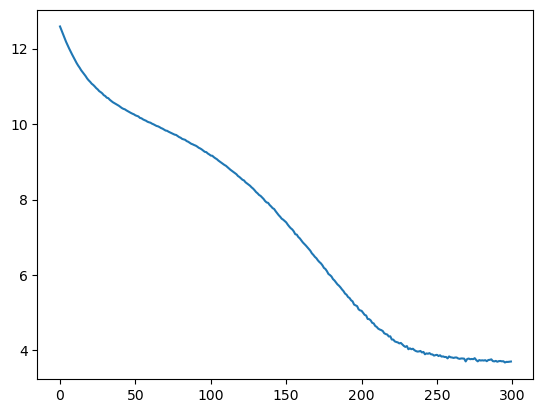

In [83]:
losses_numpy = [loss.detach().numpy() for loss in losses]

plt.plot(range(epochs), losses_numpy)
plt.show()

In [84]:
with torch.no_grad():
    y_val = model(cat_test, con_test)
    loss = torch.sqrt(criterion(y_val, y_test))

In [85]:
loss

tensor(3.6962)

In [86]:
for i in range(10):
    print(f'{i}.) Predicted: {y_val[i]}')

0.) Predicted: tensor([4.4602])
1.) Predicted: tensor([24.9646])
2.) Predicted: tensor([9.1611])
3.) Predicted: tensor([14.6446])
4.) Predicted: tensor([5.7319])
5.) Predicted: tensor([2.9218])
6.) Predicted: tensor([7.3492])
7.) Predicted: tensor([14.7402])
8.) Predicted: tensor([3.1737])
9.) Predicted: tensor([10.1951])


In [87]:
for i in range(10):
    print(f'{i}.) Predicted: {y_val[i].item():8.2f} True: {y_test[i].item():8.2f}')

0.) Predicted:     4.46 True:     2.90
1.) Predicted:    24.96 True:     5.70
2.) Predicted:     9.16 True:     7.70
3.) Predicted:    14.64 True:    12.50
4.) Predicted:     5.73 True:     4.10
5.) Predicted:     2.92 True:     5.30
6.) Predicted:     7.35 True:     3.70
7.) Predicted:    14.74 True:    14.50
8.) Predicted:     3.17 True:     5.70
9.) Predicted:    10.20 True:    10.10


In [88]:
for i in range(10):
    diff = np.abs(y_val[i].item()-y_test[i].item())
    print(f'{i}.) Predicted: {y_val[i].item():8.2f} True: {y_test[i].item():8.2f} Diff: {diff:8.2f}')

0.) Predicted:     4.46 True:     2.90 Diff:     1.56
1.) Predicted:    24.96 True:     5.70 Diff:    19.26
2.) Predicted:     9.16 True:     7.70 Diff:     1.46
3.) Predicted:    14.64 True:    12.50 Diff:     2.14
4.) Predicted:     5.73 True:     4.10 Diff:     1.63
5.) Predicted:     2.92 True:     5.30 Diff:     2.38
6.) Predicted:     7.35 True:     3.70 Diff:     3.65
7.) Predicted:    14.74 True:    14.50 Diff:     0.24
8.) Predicted:     3.17 True:     5.70 Diff:     2.53
9.) Predicted:    10.20 True:    10.10 Diff:     0.10


In [89]:
torch.save(model.state_dict(),'MM_TaxiModel.pt')